# Model 1 — EfficientNet-B0 Encoder + Transformer Decoder

**Architecture choice & rationale.** The team baseline approaches all combine a CNN encoder with a recurrent decoder (LSTM or GRU), with or without additive/multiplicative attention over the spatial feature map. To produce a *complementary* result rather than a redundant one, this notebook replaces the recurrent decoder with a **standard Transformer decoder**

**Architectural summary:**

| Component | Choice |
|---|---|
| Encoder | EfficientNet-B0 (ImageNet pretrained, frozen) — final 7×7×1280 feature map |
| Image projection | Linear 1280 → 256 (`d_model`) |
| Decoder | 3-layer Transformer decoder, 8 heads, FFN 1024, pre-LN, dropout 0.1 |
| Positional encoding | Learned (caption side only — image tokens are unordered spatial features) |
| Loss | Cross-entropy with label smoothing 0.1, ignoring `<pad>` |
| Optimizer | AdamW (lr 3e-4, weight decay 0.01) |
| LR schedule | Linear warmup (4 ep) → cosine decay (16 ep) |
| Inference | Greedy decoding |


## 1. Setup

In [1]:
import math
import pickle
import random
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


## 2. Paths & artefacts

In [3]:
PROJECT_ROOT  = Path("..").resolve()
DATA_DIR      = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Processed dir exists:", PROCESSED_DIR.exists())


Processed dir exists: True


In [4]:
# We must redefine Vocabulary in this notebook so unpickling works.
# (Pickle stores class *references*, not the class itself.)
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)


In [5]:
with open(PROCESSED_DIR / "vocab.pkl", "rb") as f:
    vocab = pickle.load(f)
with open(PROCESSED_DIR / "train_data.pkl", "rb") as f:
    train_data = pickle.load(f)
with open(PROCESSED_DIR / "val_data.pkl", "rb") as f:
    val_data = pickle.load(f)
with open(PROCESSED_DIR / "test_data.pkl", "rb") as f:
    test_data = pickle.load(f)
with open(PROCESSED_DIR / "config.pkl", "rb") as f:
    config = pickle.load(f)

VOCAB_SIZE = len(vocab)
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = vocab.pad_idx, vocab.start_idx, vocab.end_idx, vocab.unk_idx

print(f"vocab_size = {VOCAB_SIZE}")
print(f"train = {len(train_data)}  val = {len(val_data)}  test = {len(test_data)}")
print(f"config = {config}")


vocab_size = 3214
train = 5279  val = 1131  test = 1132
config = {'random_seed': 42, 'min_word_freq': 5, 'max_caption_length': 25, 'min_caption_length': 3, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'filter_rejected': True, 'filter_precanned': True, 'vocab_size': 3214, 'imagenet_mean': [0.485, 0.456, 0.406], 'imagenet_std': [0.229, 0.224, 0.225]}


## 3. Transforms, Dataset, DataLoaders

Identical to the shared notebook so all models are trained on identical inputs.

In [6]:
IMAGENET_MEAN = config["imagenet_mean"]
IMAGENET_STD  = config["imagenet_std"]

def get_train_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_eval_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [7]:
class VizWizCaptionDataset(Dataset):
    """
    train mode: returns (image, caption_ids) for one image-caption pair.
    eval  mode: returns (image, list_of_reference_caption_ids) per image.
    """
    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in ("train", "eval")
        self.data, self.vocab, self.transform, self.mode = data, vocab, transform, mode
        if mode == "train":
            self.samples = [
                (item["image_path"], cap)
                for item in data for cap in item["captions_tokens"]
            ]
        else:
            self.samples = [
                (item["image_path"], item["captions_tokens"])
                for item in data
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, caps = self.samples[idx]
        image = self.transform(Image.open(path).convert("RGB"))
        if self.mode == "train":
            return image, torch.tensor(self.vocab.encode(caps), dtype=torch.long)
        refs = [self.vocab.encode(c, add_special=False) for c in caps]
        return image, refs


def collate_train(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images, dim=0)
    lengths  = torch.tensor([len(c) for c in captions], dtype=torch.long)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    return images, captions, lengths

def collate_eval(batch):
    images, refs = zip(*batch)
    return torch.stack(images, dim=0), list(refs)


In [8]:
BATCH_SIZE = 256

train_ds = VizWizCaptionDataset(train_data, vocab, get_train_transform(), mode="train")
val_ds   = VizWizCaptionDataset(val_data,   vocab, get_eval_transform(),  mode="eval")
test_ds  = VizWizCaptionDataset(test_data,  vocab, get_eval_transform(),  mode="eval")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate_train)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_eval)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_eval)

print(f"train_pairs={len(train_ds)}  val_imgs={len(val_ds)}  test_imgs={len(test_ds)}")
imgs, caps, lens = next(iter(train_loader))
print("batch:", imgs.shape, caps.shape, "lens", lens[:5].tolist())


train_pairs=23176  val_imgs=1131  test_imgs=1132
batch: torch.Size([256, 3, 224, 224]) torch.Size([256, 27]) lens [13, 13, 12, 10, 12]


## 4. Encoder — EfficientNet-B0 (frozen)

I use the **final 7×7×1280 feature map** (output of the last conv block in `model.features`) and project it linearly to `d_model=256`. The 49 spatial positions become the **memory** tokens that the Transformer decoder cross-attends to.

Encoder is frozen for Model 1 — fine-tuning the encoder is a natural extension to consider for Model 2.

In [9]:
class EfficientNetEncoder(nn.Module):
    """Frozen EfficientNet-B0 → linearly projects spatial features to d_model."""

    def __init__(self, d_model=256, dropout=0.1):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT
        backbone = efficientnet_b0(weights=weights)
        # backbone.features outputs (B, 1280, 7, 7)
        self.features = backbone.features
        self.feature_dim = 1280

        for p in self.features.parameters():
            p.requires_grad = False

        self.projection = nn.Linear(self.feature_dim, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, images):
        # images: (B, 3, 224, 224)
        with torch.no_grad():
            feats = self.features(images)              # (B, 1280, 7, 7)
        B, C, H, W = feats.shape
        feats = feats.flatten(2).transpose(1, 2)       # (B, 49, 1280)
        feats = self.projection(feats)                 # (B, 49, d_model)
        feats = self.layer_norm(feats)
        feats = self.dropout(feats)
        return feats                                   # memory for decoder


# Smoke-test
_enc = EfficientNetEncoder(d_model=256).to(device).eval()
with torch.no_grad():
    _out = _enc(imgs.to(device))
print("Encoder output:", _out.shape)
del _enc


Encoder output: torch.Size([256, 49, 256])


## 5. Decoder — Transformer

Standard Transformer decoder built from `nn.TransformerDecoderLayer`:

* **Token embeddings** scaled by √d_model (the original "Attention Is All You Need" convention).
* **Learned positional embeddings** on the caption side, sized to `max_len`. Learned positional embeddings outperform sinusoidal at this short sequence length because the model can specialise the position vectors for caption-typical patterns (e.g. position 0 is almost always a determiner).
* **Pre-LN** (`norm_first=True`) — more stable than post-LN at small batch sizes, and removes the need for an aggressive warmup-only LR schedule.
* **Causal mask** on the caption (`tgt_mask`) so each position only sees earlier tokens.
* **Padding mask** (`tgt_key_padding_mask`) so attention ignores `<pad>` tokens.
* **No image-side mask** — all 49 spatial tokens are always valid memory.

In [10]:
class TransformerCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30, pad_idx=0):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.max_len = max_len

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding   = nn.Embedding(max_len,   d_model)
        self.embed_dropout   = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, norm_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_embedding.weight,   mean=0.0, std=0.02)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)

    def _embed(self, captions):
        B, T = captions.shape
        positions = torch.arange(T, device=captions.device).unsqueeze(0).expand(B, T)
        x = self.token_embedding(captions) * math.sqrt(self.d_model) \
            + self.pos_embedding(positions)
        return self.embed_dropout(x)

    def forward(self, memory, captions):
        """memory: (B, 49, d_model)   captions: (B, T) — teacher-forced."""
        T = captions.size(1)
        x = self._embed(captions)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(captions.device)
        tgt_kpm  = (captions == self.pad_idx)
        out = self.transformer(tgt=x, memory=memory,
                               tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_kpm)
        return self.fc_out(out)  # (B, T, V)

    @torch.no_grad()
    def generate_greedy(self, memory, start_idx, end_idx, max_len=25):
        B = memory.size(0)
        device = memory.device
        ys = torch.full((B, 1), start_idx, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)
        for _ in range(max_len):
            logits = self.forward(memory, ys)
            next_tok = logits[:, -1, :].argmax(dim=-1)
            next_tok = torch.where(finished, torch.full_like(next_tok, self.pad_idx), next_tok)
            ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            finished = finished | (next_tok == end_idx)
            if finished.all(): break
        return ys


## 6. Full model

In [11]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30,
                 pad_idx=0, start_idx=1, end_idx=2):
        super().__init__()
        self.encoder = EfficientNetEncoder(d_model=d_model, dropout=dropout)
        self.decoder = TransformerCaptionDecoder(
            vocab_size=vocab_size, d_model=d_model, nhead=nhead,
            num_layers=num_layers, dim_feedforward=dim_feedforward,
            dropout=dropout, max_len=max_len, pad_idx=pad_idx,
        )
        self.start_idx = start_idx
        self.end_idx   = end_idx

    def forward(self, images, captions):
        memory = self.encoder(images)
        return self.decoder(memory, captions)

    @torch.no_grad()
    def generate(self, images, max_len=25):
        self.eval()
        memory = self.encoder(images)
        return self.decoder.generate_greedy(memory, self.start_idx, self.end_idx, max_len=max_len)


In [12]:
# Instantiate and inspect parameter counts
D_MODEL         = 256
NHEAD           = 8
NUM_LAYERS      = 3
DIM_FEEDFORWARD = 1024
DROPOUT         = 0.1
MAX_LEN         = config["max_caption_length"] + 5   # extra room for <start>/<end> + safety

model = ImageCaptioningModel(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
    num_layers=NUM_LAYERS, dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT, max_len=MAX_LEN,
    pad_idx=PAD_IDX, start_idx=SOS_IDX, end_idx=EOS_IDX,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params    : {total:,}  (frozen = {total-trainable:,})")


Trainable params: 5,145,230
Total params    : 9,152,778  (frozen = 4,007,548)


## 7. Training

* **Loss:** cross-entropy with `label_smoothing=0.1` (standard Transformer recipe — improves generalisation, mildly regularises overconfident predictions). `<pad>` tokens are ignored.
* **Optimizer:** AdamW (lr 3e-4, weight decay 0.01) — only decoder + projection parameters update; encoder is frozen.
* **LR schedule:** linear warmup over `WARMUP_EPOCHS` then cosine decay to zero. Warmup is important for Transformer training even with pre-LN.
* **Gradient clipping:** ‖g‖ ≤ 1.0.
* **Checkpointing:** save best model by validation loss.

In [13]:
# Hyperparameters
LEARNING_RATE  = 3e-4
WEIGHT_DECAY   = 0.01
LABEL_SMOOTH   = 0.1
GRAD_CLIP      = 1.0
NUM_EPOCHS     = 20
WARMUP_EPOCHS  = 4

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.98), eps=1e-9,
)

steps_per_epoch = len(train_loader)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"steps_per_epoch={steps_per_epoch}  total_steps={total_steps}  warmup_steps={warmup_steps}")


steps_per_epoch=91  total_steps=1820  warmup_steps=364


In [14]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, clip):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for images, captions, _ in pbar:
        images, captions = images.to(device), captions.to(device)
        inputs  = captions[:, :-1]    # decoder input  (<start> + words)
        targets = captions[:,  1:]    # decoder target (words + <end>)

        logits = model(images, inputs)                              # (B, T-1, V)
        loss = criterion(logits.reshape(-1, logits.size(-1)),
                         targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()

        running += loss.item() * images.size(0)
        n       += images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    return running / n


@torch.no_grad()
def validate_loss(model, val_data, vocab, transform, criterion, device, batch_size=32):
    """Compute val cross-entropy by re-pairing each image with each of its 5 captions."""
    model.eval()
    pairs = [(item["image_path"], cap)
             for item in val_data for cap in item["captions_tokens"]]
    total_loss, total_n = 0.0, 0
    for start in range(0, len(pairs), batch_size):
        chunk = pairs[start:start + batch_size]
        imgs = torch.stack([transform(Image.open(p).convert("RGB")) for p, _ in chunk]).to(device)
        cap_ids = [torch.tensor(vocab.encode(c), dtype=torch.long) for _, c in chunk]
        cap_pad = pad_sequence(cap_ids, batch_first=True, padding_value=PAD_IDX).to(device)
        inputs, targets = cap_pad[:, :-1], cap_pad[:, 1:]
        logits = model(imgs, inputs)
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        total_loss += loss.item() * imgs.size(0)
        total_n    += imgs.size(0)
    return total_loss / total_n


In [15]:
history = {"train_loss": [], "val_loss": []}
best_val = float("inf")
best_path = CHECKPOINT_DIR / "model1_transformer_best.pt"
val_transform_for_loss = get_eval_transform()

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                              criterion, device, GRAD_CLIP)
    vl_loss = validate_loss(model, val_data, vocab, val_transform_for_loss,
                            criterion, device)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    elapsed = time.time() - t0
    flag = ""
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save({"model": model.state_dict(),
                    "epoch": epoch, "val_loss": vl_loss},
                   best_path)
        flag = "  ✓ saved"
    print(f"epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"train={tr_loss:.4f}  val={vl_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  "
          f"elapsed={elapsed/60:.1f}m{flag}")

print(f"\nbest val loss: {best_val:.4f}  →  {best_path.name}")


train:   0%|          | 0/91 [00:00<?, ?it/s]

/home/billionaire-bros/setup/venv/lib/python3.12/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


epoch 01/20  train=6.9918  val=5.4914  lr=7.58e-05  elapsed=11.2m  ✓ saved


train:   0%|          | 0/91 [00:00<?, ?it/s]

epoch 02/20  train=5.1411  val=4.7493  lr=1.51e-04  elapsed=20.4m  ✓ saved


...

epoch 18/20  train=3.3372  val=4.0579  lr=1.14e-05  elapsed=167.0m


train:   0%|          | 0/91 [00:00<?, ?it/s]

epoch 19/20  train=3.3286  val=4.0585  lr=2.88e-06  elapsed=176.2m


train:   0%|          | 0/91 [00:00<?, ?it/s]

epoch 20/20  train=3.3255  val=4.0583  lr=0.00e+00  elapsed=185.3m

best val loss: 4.0374  →  model1_transformer_best.pt


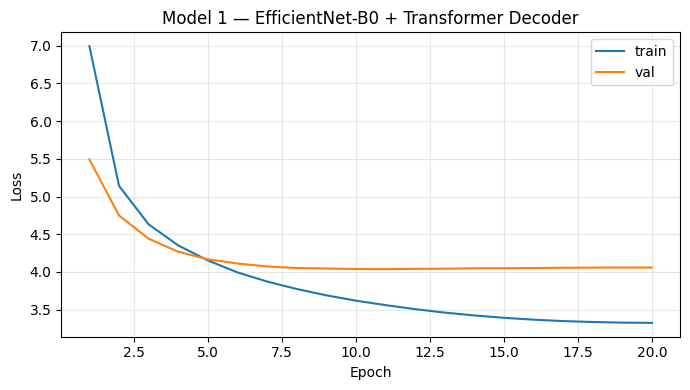

In [16]:
# Training curves
fig, ax = plt.subplots(figsize=(7, 4))
xs = range(1, len(history["train_loss"]) + 1)
ax.plot(xs, history["train_loss"], label="train")
ax.plot(xs, history["val_loss"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Model 1 — EfficientNet-B0 + Transformer Decoder")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. BLEU evaluation
* `corpus_bleu` from NLTK with `SmoothingFunction.method1`.
* References = all 5 ground-truth captions per image (already encoded without special tokens by the dataset).
* Candidate = greedy decode, special tokens stripped.

In [17]:
# Reload best checkpoint
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")


Loaded checkpoint from epoch 11  (val_loss=4.0374)


In [18]:
smoothie = SmoothingFunction().method1

def ids_to_tokens(ids, strip_special=True):
    """Decode token ids to a list of word tokens (for BLEU)."""
    out = []
    for i in ids:
        w = vocab.idx2word.get(int(i), vocab.UNK)
        if strip_special:
            if w == vocab.END: break
            if w in (vocab.PAD, vocab.START): continue
        out.append(w)
    return out


@torch.no_grad()
def evaluate_bleu(model, loader, device, max_batches=None, max_gen_len=25):
    model.eval()
    all_refs, all_hyps = [], []
    pbar = tqdm(loader, desc="BLEU eval", leave=False)
    for batch_idx, (images, refs_batch) in enumerate(pbar):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device)
        gen_ids = model.generate(images, max_len=max_gen_len)
        for refs, hyp_ids in zip(refs_batch, gen_ids.tolist()):
            hyp = ids_to_tokens(hyp_ids, strip_special=True)
            ref_tokens = [ids_to_tokens(r, strip_special=False) for r in refs]
            # refs were encoded with add_special=False, so they're already clean
            all_refs.append(ref_tokens)
            all_hyps.append(hyp)

    return {
        "BLEU-1": corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0), smoothing_function=smoothie),
        "BLEU-2": corpus_bleu(all_refs, all_hyps, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        "BLEU-3": corpus_bleu(all_refs, all_hyps, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        "BLEU-4": corpus_bleu(all_refs, all_hyps, weights=(0.25,)*4, smoothing_function=smoothie),
        "n_examples": len(all_hyps),
    }


In [19]:
val_bleu = evaluate_bleu(model, val_loader, device)
print("Validation BLEU:")
for k, v in val_bleu.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


BLEU eval:   0%|          | 0/71 [00:00<?, ?it/s]

Validation BLEU:
  BLEU-1: 0.5589
  BLEU-2: 0.3619
  BLEU-3: 0.2280
  BLEU-4: 0.1452
  n_examples: 1131


In [20]:
test_bleu = evaluate_bleu(model, test_loader, device)
print("Test BLEU:")
for k, v in test_bleu.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


BLEU eval:   0%|          | 0/71 [00:00<?, ?it/s]

Test BLEU:
  BLEU-1: 0.5552
  BLEU-2: 0.3544
  BLEU-3: 0.2207
  BLEU-4: 0.1361
  n_examples: 1132


## 9. Qualitative samples

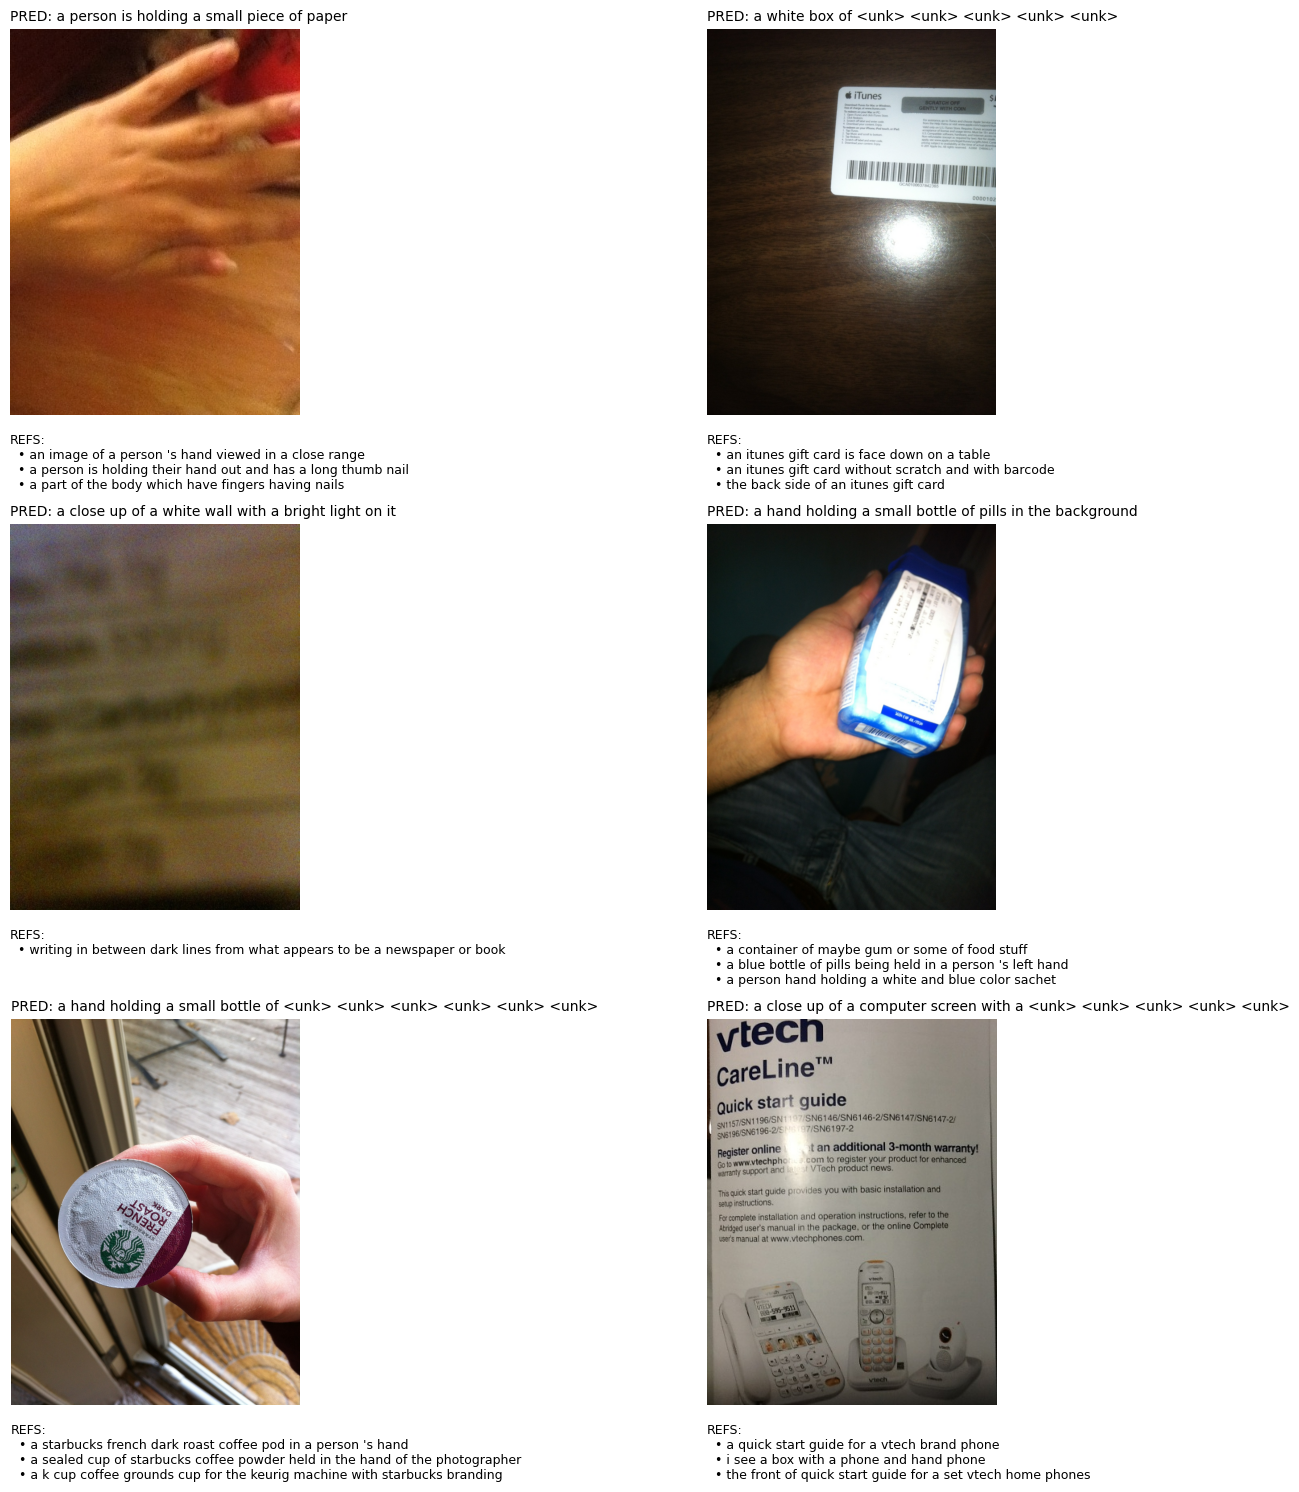

In [21]:
@torch.no_grad()
def show_samples(items, n=6):
    """items: list of dicts with image_path + captions_tokens (e.g. from test_data)"""
    model.eval()
    picks = random.sample(items, n)
    eval_tf = get_eval_transform()
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flat if rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

    for ax, item in zip(axes, picks):
        img = Image.open(item["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

        tensor = eval_tf(img).unsqueeze(0).to(device)
        gen_ids = model.generate(tensor, max_len=25)[0].tolist()
        pred = " ".join(ids_to_tokens(gen_ids, strip_special=True))

        refs = "\n".join(f"  • {' '.join(c)}" for c in item["captions_tokens"][:3])
        ax.set_title(f"PRED: {pred}", fontsize=10, loc="left")
        ax.text(0, -0.05, f"REFS:\n{refs}", transform=ax.transAxes,
                fontsize=9, va="top", wrap=True)
    plt.tight_layout()
    plt.show()

show_samples(test_data, n=6)


## 10. Performance summary

In [22]:
summary = pd.DataFrame({
    "Metric": [
        "Architecture", "Encoder", "Decoder", "d_model", "Decoder layers",
        "Attention heads", "Trainable params", "Frozen params",
        "Device used", "Epochs", "Best validation loss",
        "BLEU-1 (val)", "BLEU-2 (val)", "BLEU-3 (val)", "BLEU-4 (val)",
        "BLEU-1 (test)", "BLEU-2 (test)", "BLEU-3 (test)", "BLEU-4 (test)",
    ],
    "Result": [
        "EfficientNet-B0 + Transformer Decoder",
        "EfficientNet-B0 (frozen, ImageNet)",
        "Transformer (cross-attention)",
        D_MODEL, NUM_LAYERS, NHEAD,
        f"{trainable:,}", f"{total - trainable:,}",
        "CUDA / GPU" if device.type == "cuda" else "CPU",
        NUM_EPOCHS, f"{best_val:.4f}",
        f"{val_bleu['BLEU-1']:.4f}", f"{val_bleu['BLEU-2']:.4f}",
        f"{val_bleu['BLEU-3']:.4f}", f"{val_bleu['BLEU-4']:.4f}",
        f"{test_bleu['BLEU-1']:.4f}", f"{test_bleu['BLEU-2']:.4f}",
        f"{test_bleu['BLEU-3']:.4f}", f"{test_bleu['BLEU-4']:.4f}",
    ],
})
print("Model 1 Performance Summary")
print("=" * 60)
summary.to_string(index=False)


Model 1 Performance Summary


'              Metric                                Result\n        Architecture EfficientNet-B0 + Transformer Decoder\n             Encoder    EfficientNet-B0 (frozen, ImageNet)\n             Decoder         Transformer (cross-attention)\n             d_model                                   256\n      Decoder layers                                     3\n     Attention heads                                     8\n    Trainable params                             5,145,230\n       Frozen params                             4,007,548\n         Device used                            CUDA / GPU\n              Epochs                                    20\nBest validation loss                                4.0374\n        BLEU-1 (val)                                0.5589\n        BLEU-2 (val)                                0.3619\n        BLEU-3 (val)                                0.2280\n        BLEU-4 (val)                                0.1452\n       BLEU-1 (test)                   

In [2]:
print("""Model 1 Performance Summary
============================================================
              Metric                                Result\n        Architecture EfficientNet-B0 + Transformer Decoder\n             Encoder    EfficientNet-B0 (frozen, ImageNet)\n             Decoder         Transformer (cross-attention)\n             d_model                                   256\n      Decoder layers                                     3\n     Attention heads                                     8\n    Trainable params                             5,145,230\n       Frozen params                             4,007,548\n         Device used                            CUDA / GPU\n              Epochs                                    20\nBest validation loss                                4.0374\n        BLEU-1 (val)                                0.5589\n        BLEU-2 (val)                                0.3619\n        BLEU-3 (val)                                0.2280\n        BLEU-4 (val)                                0.1452\n       BLEU-1 (test)                                0.5552\n       BLEU-2 (test)                                0.3544\n       BLEU-3 (test)                                0.2207\n       BLEU-4 (test)                                0.1361""")

Model 1 Performance Summary
              Metric                                Result
        Architecture EfficientNet-B0 + Transformer Decoder
             Encoder    EfficientNet-B0 (frozen, ImageNet)
             Decoder         Transformer (cross-attention)
             d_model                                   256
      Decoder layers                                     3
     Attention heads                                     8
    Trainable params                             5,145,230
       Frozen params                             4,007,548
         Device used                            CUDA / GPU
              Epochs                                    20
Best validation loss                                4.0374
        BLEU-1 (val)                                0.5589
        BLEU-2 (val)                                0.3619
        BLEU-3 (val)                                0.2280
        BLEU-4 (val)                                0.1452
       BLEU-1 (test)        

In [23]:
# Save full results bundle for cross-model comparison & report
results = {
    "model_name":        "Model 1 EfficientNet-B0 + Transformer Decoder",
    "encoder":           "EfficientNet-B0",
    "decoder":           "Transformer",
    "attention":         "Multi-head cross-attention (built into Transformer decoder)",
    "d_model":           D_MODEL,
    "num_decoder_layers": NUM_LAYERS,
    "nhead":             NHEAD,
    "dim_feedforward":   DIM_FEEDFORWARD,
    "dropout":           DROPOUT,
    "label_smoothing":   LABEL_SMOOTH,
    "epochs":            NUM_EPOCHS,
    "warmup_epochs":     WARMUP_EPOCHS,
    "peak_lr":           LEARNING_RATE,
    "weight_decay":      WEIGHT_DECAY,
    "best_val_loss":     best_val,
    "trainable_params":  trainable,
    "history":           history,
    "val_bleu":          val_bleu,
    "test_bleu":         test_bleu,
}
with open(CHECKPOINT_DIR / "model1_transformer_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Saved → checkpoints/model1_transformer_results.pkl")


Saved → checkpoints/model1_transformer_results.pkl
